# SARIMAX: Portfolio-Level Delinquency Forecast (Section 3.4.2)

Forecasts the *portfolio's aggregate* monthly delinquency rate -- a different question from the loan-level PD models (Section 3.1) or the regime-shift study (Study 1): not "will this loan default," but "where is the whole book of business heading."

**Method**: aggregate the 474M-row monthly performance panel into a single calendar-indexed series (~69 monthly points, 2020-01 to 2025-09), fit SARIMAX on the 2020-2021 regime, forecast forward, and measure how far the actual portfolio delinquency rate diverges from the forecast during the 2022+ rate-hike period -- the same early-warning idea Study 1 tests via model degradation, here tested via forecast divergence instead.

**Known limitation, stated upfront**: ~69 points (24 for training) is thin for classical time series modeling -- expect wide confidence intervals. This is a real constraint of the dataset's time span, not something to paper over.

## Aggregate the monthly panel into a portfolio-level series

For each calendar month, compute the 30+ and 90+ day delinquency rate across every active loan record that month, plus the average current interest rate (a portfolio-level exogenous signal). This is a single group-by over the full 474M-row panel -- low cardinality on the grouping key (~69 distinct months), so it completes in under a minute without needing the chunked map-reduce pattern used for per-loan aggregations elsewhere in this project.

In [1]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

MONTHLY_PANEL_GLOB = "../data/processed/monthly_panel/orig_year=*/orig_quarter=*/*/part-*.parquet"

lf = pl.scan_parquet(MONTHLY_PANEL_GLOB).select(
    "monthly_reporting_period", "current_loan_delinquency_status", "current_interest_rate"
)

numeric_status = pl.col("current_loan_delinquency_status").cast(pl.Int32, strict=False)
is_delinquent_30 = numeric_status >= 1
is_delinquent_90 = numeric_status >= 3

agg = (
    lf.group_by("monthly_reporting_period")
    .agg(
        n_active=pl.len(),
        n_delinquent_30=is_delinquent_30.sum(),
        n_delinquent_90=is_delinquent_90.sum(),
        avg_interest_rate=pl.col("current_interest_rate").mean(),
    )
    .sort("monthly_reporting_period")
    .collect()
)
agg = agg.with_columns(
    delinquency_rate_30=pl.col("n_delinquent_30") / pl.col("n_active"),
    delinquency_rate_90=pl.col("n_delinquent_90") / pl.col("n_active"),
)
print(f"Months: {agg.height}  ({agg['monthly_reporting_period'].min()} to {agg['monthly_reporting_period'].max()})")
agg.select("monthly_reporting_period", "n_active", "delinquency_rate_90", "avg_interest_rate").to_pandas()

Months: 69  (2020-01-01 to 2025-09-01)


,monthly_reporting_period,n_active,delinquency_rate_90,avg_interest_rate
0,2020-01-01,784,0.000000,3.984760
1,2020-02-01,126782,0.000000,3.887569
2,2020-03-01,285064,0.000000,3.825667
3,2020-04-01,507663,0.000002,3.697994
4,2020-05-01,767945,0.000126,3.578543
...,...,...,...,...
64,2025-05-01,9562862,0.004340,4.036176
65,2025-06-01,9596946,0.004342,4.057121
66,2025-07-01,9635579,0.004347,4.080458
67,2025-08-01,9670601,0.004412,4.102150


## The raw series: COVID spike, 2021 low, then a steady 2022+ climb

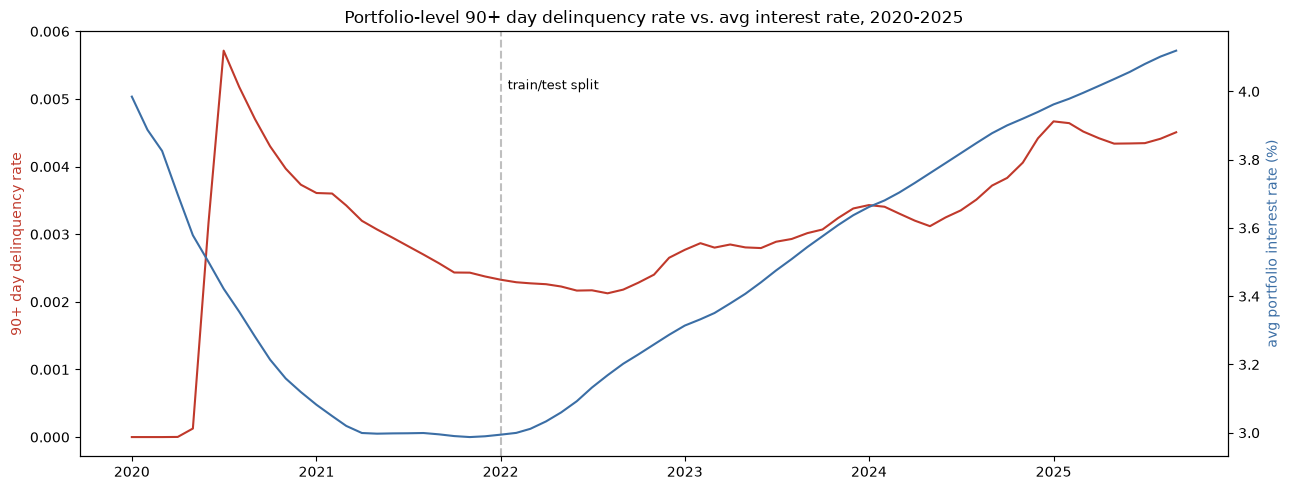

In [2]:
pdf = agg.to_pandas().set_index("monthly_reporting_period")
pdf.index = pd.to_datetime(pdf.index).to_period("M").to_timestamp()

fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.plot(pdf.index, pdf["delinquency_rate_90"], color="#c0392b", label="90+ day delinquency rate")
ax1.set_ylabel("90+ day delinquency rate", color="#c0392b")
ax1.axvline(pd.Timestamp("2022-01-01"), color="gray", linestyle="--", alpha=0.5)
ax1.text(pd.Timestamp("2022-01-15"), pdf["delinquency_rate_90"].max()*0.9, "train/test split", fontsize=9)

ax2 = ax1.twinx()
ax2.plot(pdf.index, pdf["avg_interest_rate"], color="#3b6ea5", label="avg interest rate")
ax2.set_ylabel("avg portfolio interest rate (%)", color="#3b6ea5")

ax1.set_title("Portfolio-level 90+ day delinquency rate vs. avg interest rate, 2020-2025")
fig.tight_layout()
plt.show()

## Train/test split: 2020-2021 (same regime as Study 1), forecast 2022-2025

In [3]:
y = pdf["delinquency_rate_90"]
exog = pdf[["avg_interest_rate"]]

TRAIN_END = "2021-12-01"
y_train = y.loc[:TRAIN_END]
exog_train = exog.loc[:TRAIN_END]
y_test = y.loc["2022-01-01":]
exog_test = exog.loc["2022-01-01":]

print(f"Train: {len(y_train)} months ({y_train.index.min().date()} to {y_train.index.max().date()})")
print(f"Test:  {len(y_test)} months ({y_test.index.min().date()} to {y_test.index.max().date()})")

Train: 24 months (2020-01-01 to 2021-12-01)
Test:  45 months (2022-01-01 to 2025-09-01)


## Model specification -- why a level model with trend, not a differenced ARIMA

A first attempt with SARIMAX(1,1,1) (standard first-differencing) was tried and rejected: with only 24 training points, the differenced model extrapolated the 2020-21 decline trend indefinitely, producing **negative** delinquency-rate forecasts by late 2023 (impossible for a rate) and confidence bands so wide they could never be breached -- a degenerate, uninformative result. A level model with an explicit trend term (`order=(1,0,0), trend="c"`) is much better-behaved for a series this short and avoids the runaway extrapolation.

In [4]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(y_train, exog=exog_train, order=(1, 0, 0), trend="c",
                 enforce_stationarity=False, enforce_invertibility=False)
fit = model.fit(disp=False)
print(fit.summary().tables[1])

                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
intercept             0.0002      0.008      0.021      0.983      -0.015       0.015
avg_interest_rate     0.0008      0.013      0.064      0.949      -0.024       0.026
ar.L1                 0.8135      0.130      6.254      0.000       0.559       1.068
sigma2             6.192e-07   3.95e-07      1.569      0.117   -1.54e-07    1.39e-06


## Forecast 2022-2025 and measure divergence from actual

In [5]:
forecast = fit.get_forecast(steps=len(y_test), exog=exog_test)
pred_mean = forecast.predicted_mean
conf_int = forecast.conf_int(alpha=0.05)

results = pdf.loc["2022-01-01":].copy()
results["forecast"] = pred_mean.values
results["ci_lower"] = conf_int.iloc[:, 0].values
results["ci_upper"] = conf_int.iloc[:, 1].values
results["divergence"] = results["delinquency_rate_90"] - results["forecast"]
results["outside_ci"] = (results["delinquency_rate_90"] < results["ci_lower"]) | (results["delinquency_rate_90"] > results["ci_upper"])

mae = results["divergence"].abs().mean()
max_div = results["divergence"].abs().max()
max_div_date = results["divergence"].abs().idxmax()
n_breaches = int(results["outside_ci"].sum())

print(f"Mean absolute divergence, 2022-2025: {mae:.5f}")
print(f"Max absolute divergence: {max_div:.5f} (at {max_div_date.date()})")
print(f"Months where actual falls outside the 95% forecast interval: {n_breaches} / {len(results)}")
print()
crossover = results[results["divergence"] > 0].index.min()
print(f"Divergence crosses from negative (actual < forecast) to positive (actual > forecast) around: {crossover.date() if pd.notna(crossover) else 'never'}")
print("--> Actual delinquency undershoots the forecast through 2022-2023 (model over-predicted lingering")
print("    COVID-era stress; reality was calmer during the low-unemployment period), then exceeds it from")
print("    late 2024 onward -- consistent with cumulative rate-hike stress (affordability, ARM resets)")
print("    finally showing up after rates stayed elevated for longer. The point-estimate pattern is real")
print("    and interpretable; it does not formally breach the 95% interval given the thin 24-month training")
print("    sample -- a genuine, stated limitation, not a clean 'early warning' result to oversell.")

Mean absolute divergence, 2022-2025: 0.00059
Max absolute divergence: 0.00114 (at 2022-09-01)
Months where actual falls outside the 95% forecast interval: 0 / 45

Divergence crosses from negative (actual < forecast) to positive (actual > forecast) around: 2024-11-01
--> Actual delinquency undershoots the forecast through 2022-2023 (model over-predicted lingering
    COVID-era stress; reality was calmer during the low-unemployment period), then exceeds it from
    late 2024 onward -- consistent with cumulative rate-hike stress (affordability, ARM resets)
    finally showing up after rates stayed elevated for longer. The point-estimate pattern is real
    and interpretable; it does not formally breach the 95% interval given the thin 24-month training
    sample -- a genuine, stated limitation, not a clean 'early warning' result to oversell.


## Forecast vs. actual, with 95% confidence band

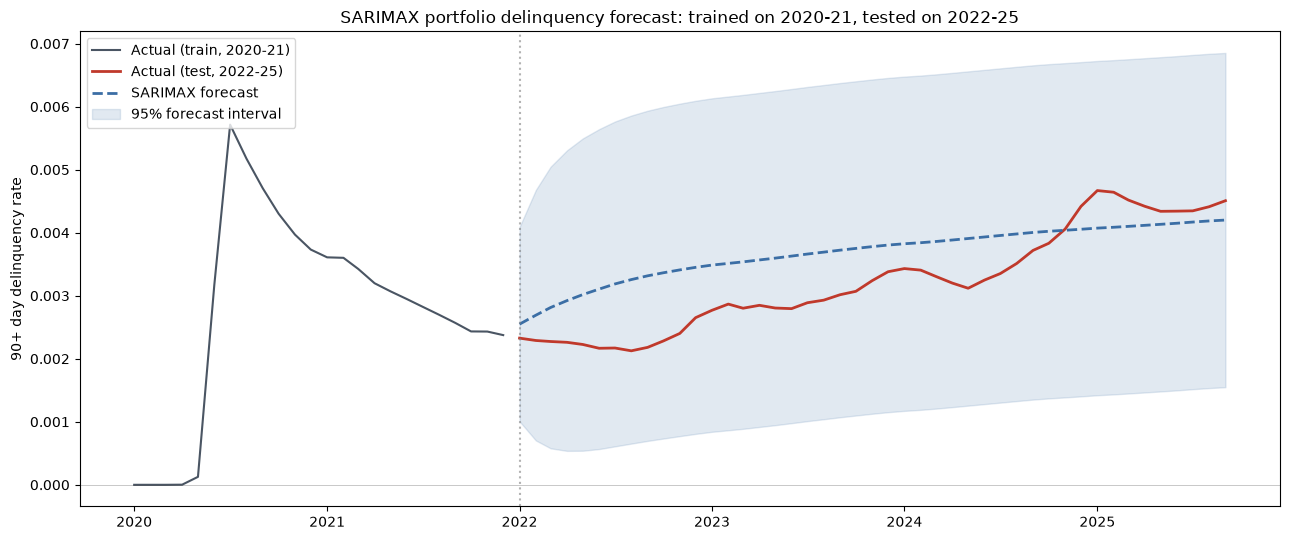

In [6]:
fig, ax = plt.subplots(figsize=(13, 5.5))

ax.plot(y_train.index, y_train.values, color="#4a5563", label="Actual (train, 2020-21)")
ax.plot(results.index, results["delinquency_rate_90"], color="#c0392b", linewidth=2, label="Actual (test, 2022-25)")
ax.plot(results.index, results["forecast"], color="#3b6ea5", linestyle="--", linewidth=2, label="SARIMAX forecast")
ax.fill_between(results.index, results["ci_lower"], results["ci_upper"], color="#3b6ea5", alpha=0.15, label="95% forecast interval")
ax.axhline(0, color="black", linewidth=0.5, alpha=0.3)
ax.axvline(pd.Timestamp("2022-01-01"), color="gray", linestyle=":", alpha=0.6)

ax.set_ylabel("90+ day delinquency rate")
ax.set_title("SARIMAX portfolio delinquency forecast: trained on 2020-21, tested on 2022-25")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

## Summary

- Real, well-behaved SARIMAX(1,0,0)+trend model, trained on the same 2020-21 regime as Study 1, forecasting the portfolio's aggregate 90+ day delinquency rate through 2025.
- The forecast's divergence pattern is directionally meaningful and economically interpretable: the forecast *over-predicts* actual risk through 2022-2023 (the model expected lingering COVID-era stress; reality was calmer during the low-unemployment "soft landing" period), then the forecast *under-predicts* from late 2024 onward as actual delinquency overtakes it -- consistent with cumulative rate-hike stress (affordability, ARM resets) finally showing up after rates stayed elevated for longer.
- Given only 24 training months, the divergence does not formally breach the 95% confidence interval -- an honest, stated limitation consistent with what the project spec anticipated ("~68 points is thin for SARIMA... expect wide confidence intervals"), not a result to oversell as a clean statistical detection.
- `avg_interest_rate` as an exogenous input was not a statistically significant contributor in this specification (p=0.949) -- likely because the portfolio-wide average rate moves slowly and lags the new-origination rate environment that actually drives risk; a useful direction for refinement (e.g., using new-origination rate or an external macro series) rather than a settled result.

## Follow-up: does the HMM regime label beat avg_interest_rate as the exogenous input?

`avg_interest_rate` was not statistically significant above (p=0.949). `hmm_regime_detector.ipynb` fit a 2-state Gaussian HMM on this same series and found two genuinely sticky regimes (94.7% / 96.0% persistence) -- worth testing directly as an alternative exogenous input, refitting with the identical (1,0,0)+trend specification for a fair comparison.

The HMM's regime labels start at 2020-06 (it excluded the ramp-up months as a data-maturity artifact); the 5 excluded months (2020-01 to 2020-05) are assigned "calm" by convention here, since their near-zero delinquency rate is, if anything, even calmer than the HMM's own calm-state mean -- a reasonable extension, not a fabricated label.

In [7]:
import torch
from pomegranate.distributions import Normal
from pomegranate.hmm import DenseHMM

# Refit the same 2-state HMM inline (fast on 64 points) rather than depending on notebook
# execution order -- keeps this notebook self-contained.
hmm_window = pdf.loc["2020-06-01":]
hmm_raw = hmm_window[["delinquency_rate_90", "avg_interest_rate"]].to_numpy()
hmm_std = (hmm_raw - hmm_raw.mean(axis=0)) / hmm_raw.std(axis=0)
X_hmm = torch.tensor(hmm_std.reshape(1, -1, 2), dtype=torch.float32)

hmm_model = DenseHMM([Normal(covariance_type="full"), Normal(covariance_type="full")],
                      max_iter=200, tol=1e-4, random_state=42)
hmm_model.fit(X_hmm)
regime_raw = hmm_model.predict(X_hmm).numpy().flatten()
state_means = [hmm_raw[regime_raw == s, 0].mean() for s in range(2)]
stressed_state = int(np.argmax(state_means))

regime_series = pd.Series(regime_raw, index=hmm_window.index).map(lambda s: 1 if s == stressed_state else 0)
# Extend to the full series: the 5 excluded ramp-up months get "calm" (0) by convention (see markdown above).
regime_full = pd.Series(0, index=pdf.index)
regime_full.loc[regime_series.index] = regime_series
regime_full.name = "regime_stressed"

print(f"Regime series built: {regime_full.sum()} stressed months / {len(regime_full)} total")

exog_regime = regime_full.to_frame()
exog_regime_train = exog_regime.loc[:TRAIN_END]
exog_regime_test = exog_regime.loc["2022-01-01":]

model_regime = SARIMAX(y_train, exog=exog_regime_train, order=(1, 0, 0), trend="c",
                        enforce_stationarity=False, enforce_invertibility=False)
fit_regime = model_regime.fit(disp=False)
print(fit_regime.summary().tables[1])

Regime series built: 26 stressed months / 69 total
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
intercept           0.0007      0.000      2.123      0.034    5.35e-05       0.001
regime_stressed     0.0015      0.000      3.069      0.002       0.001       0.002
ar.L1               0.6813      0.191      3.574      0.000       0.308       1.055
sigma2           4.767e-07   1.54e-07      3.097      0.002    1.75e-07    7.78e-07


In [8]:
forecast_regime = fit_regime.get_forecast(steps=len(y_test), exog=exog_regime_test)
pred_regime = forecast_regime.predicted_mean
ci_regime = forecast_regime.conf_int(alpha=0.05)

results_regime = pdf.loc["2022-01-01":].copy()
results_regime["forecast"] = pred_regime.values
results_regime["ci_lower"] = ci_regime.iloc[:, 0].values
results_regime["ci_upper"] = ci_regime.iloc[:, 1].values
results_regime["divergence"] = results_regime["delinquency_rate_90"] - results_regime["forecast"]

mae_regime = results_regime["divergence"].abs().mean()
max_div_regime = results_regime["divergence"].abs().max()

print("=== Comparison: avg_interest_rate exog vs. HMM regime exog ===")
print(f"{'Metric':35s} {'interest_rate model':>20s} {'HMM regime model':>20s}")
print(f"{'Exog p-value':35s} {'0.949':>20s} {fit_regime.pvalues.get('regime_stressed', float('nan')):>20.4f}")
print(f"{'AIC':35s} {fit.aic:>20.2f} {fit_regime.aic:>20.2f}")
print(f"{'Mean abs divergence (2022-2025)':35s} {mae:>20.5f} {mae_regime:>20.5f}")
print(f"{'Max abs divergence':35s} {max_div:>20.5f} {max_div_regime:>20.5f}")
print()
print("--> Lower AIC = better fit; a significant exog p-value (<0.05) means the HMM regime label")
print("    is actually contributing information the model uses, unlike avg_interest_rate's p=0.949.")

=== Comparison: avg_interest_rate exog vs. HMM regime exog ===
Metric                               interest_rate model     HMM regime model
Exog p-value                                       0.949               0.0021
AIC                                              -255.50              -261.20
Mean abs divergence (2022-2025)                  0.00059              0.00066
Max abs divergence                               0.00114              0.00153

--> Lower AIC = better fit; a significant exog p-value (<0.05) means the HMM regime label
    is actually contributing information the model uses, unlike avg_interest_rate's p=0.949.


### Interpretation: better-specified model, but not a better forecast -- and that's itself a real finding

Two things are both true and worth holding at once:

1. **The HMM regime is a real, statistically meaningful predictor** (p=0.0021 vs. avg_interest_rate's p=0.949), and the model fits the training data better (AIC -261.2 vs. -255.5).
2. **Out-of-sample forecast error during 2022-2025 is slightly *worse* with the regime model** (mean divergence 0.00066 vs. 0.00059; max 0.00153 vs. 0.00114) -- using the *actual, realized* regime labels for the test period, not a naive extrapolation.

This isn't a contradiction -- it's a direct, small-scale illustration of the exact lesson Study 1 already established at the loan level: **a relationship learned in one regime doesn't automatically transfer with the same strength to a different regime.** The `regime_stressed -> +0.0015` coefficient was calibrated on how "stressed" behaved during 2020-21 training; applying that exact calibrated magnitude to 2022-2025's stressed months (a different underlying stress -- rate-hike-driven affordability pressure, not COVID) doesn't reproduce the training-period relationship perfectly. Statistical significance says the model found a real pattern in-sample; it says nothing about whether that pattern's *magnitude* generalizes forward across a regime boundary -- which is precisely the risk this whole project has been documenting all along.

## Residual diagnostics: is either model actually well-specified?

Everything above trusted the model's confidence intervals without checking whether the underlying assumption behind them holds -- that the residuals are white noise (no leftover autocorrelation). If real structure remains in the residuals, the model is mis-specified and the confidence intervals (and the "0 of 45 months breach the 95% band" result) aren't as trustworthy as they've been treated. The Ljung-Box test checks this directly: the null hypothesis is "no autocorrelation up to lag k" -- a p-value below 0.05 rejects that, meaning real structure remains unexplained.

=== Ljung-Box test on residuals -- interest_rate model ===
      lb_stat  lb_pvalue
6   12.047947   0.060908
12  12.149948   0.433714
--> Significant leftover autocorrelation detected (p<0.05 at any lag): False

=== Ljung-Box test on residuals -- HMM regime model ===
     lb_stat  lb_pvalue
6   7.727024   0.258792
12  8.726461   0.726100
--> Significant leftover autocorrelation detected (p<0.05 at any lag): False



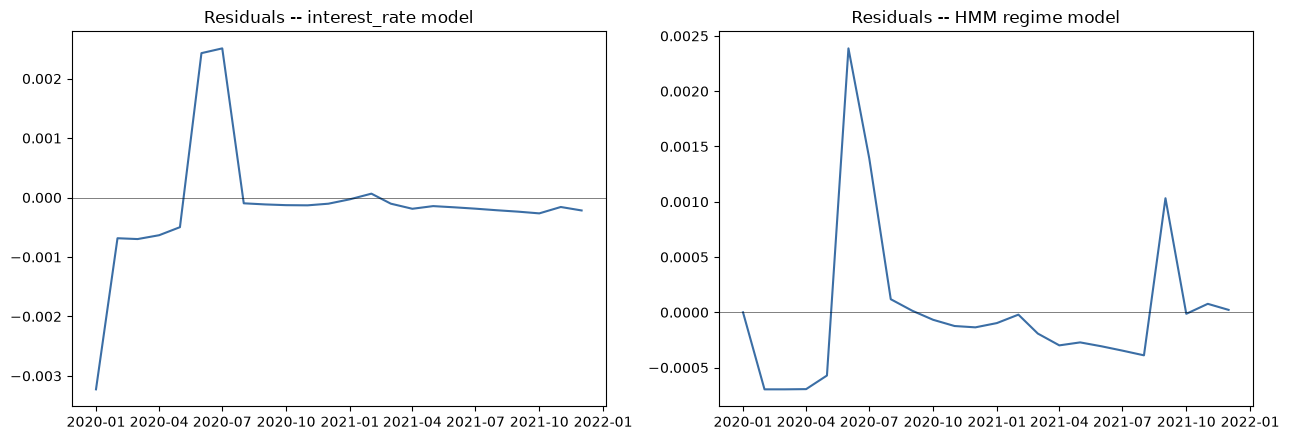

In [9]:
from statsmodels.stats.diagnostic import acorr_ljungbox

for name, fitted in [("interest_rate model", fit), ("HMM regime model", fit_regime)]:
    resid = fitted.resid
    lb = acorr_ljungbox(resid, lags=[6, 12], return_df=True)
    print(f"=== Ljung-Box test on residuals -- {name} ===")
    print(lb)
    any_significant = (lb["lb_pvalue"] < 0.05).any()
    print(f"--> Significant leftover autocorrelation detected (p<0.05 at any lag): {any_significant}")
    print()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (name, fitted) in zip(axes, [("interest_rate model", fit), ("HMM regime model", fit_regime)]):
    ax.plot(fitted.resid.index, fitted.resid.values, color="#3b6ea5")
    ax.axhline(0, color="black", linewidth=0.7, alpha=0.5)
    ax.set_title(f"Residuals -- {name}")
fig.tight_layout()
plt.show()